CUDA backend failed to initialize: Found CUDA version 11070, but JAX was built against version 11080, which is newer. The copy of CUDA that is installed must be at least as new as the version against which JAX was built. (Set TF_CPP_MIN_LOG_LEVEL=0 and rerun for more info.)


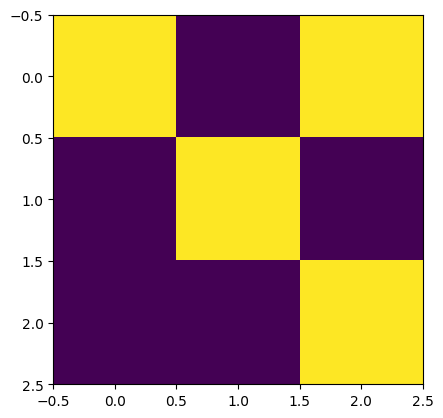

In [1]:

import jax
import jax.numpy as jnp
import matplotlib.pyplot as plt

v = jnp.array([[1, 2, 3.], [4, 5, 0], [7, 3,1]])

# Mask
mask = jnp.array([[True, False, True], [False, True, False], [False, False, True]])


plt.imshow(mask)

v = v[:,None,:]
mask = mask[None, :, :]

In [2]:
def efficient_masked_dot_product_attention(
    query,
    key,
    value,
    mask=None,
):
    pass


#indices1, indices2 = jnp.where(mask)

@jax.jit
def _efficient_masked_dot_product_single(query, key, value, indices1, indices2):

    *batch_size, seq_len, dim = query.shape


    query = jnp.take(query, indices1, axis=-2)
    key = jnp.take(key, indices2, axis=-2)
    value = jnp.take(value, indices2, axis=-2)

    # Attention logits
    attn_logits = jnp.sum(query * key, axis=-1)
    attn_logits = attn_logits / jnp.sqrt(dim).astype(key.dtype)

    # Softmax
    atten_logits = attn_logits - jnp.max(attn_logits, axis=-1, keepdims=True)
    atten_weight = jnp.exp(atten_logits)
    atten_normalizer = jax.ops.segment_sum(atten_weight, indices1, num_segments=seq_len, indices_are_sorted=True)
    atten_normalizer = jnp.take(atten_normalizer, indices1, axis=0)
    atten_weight = atten_weight / atten_normalizer

    # Attention weighted values
    attention_weighted_values =  atten_weight[:, None] * value
    updated_values = jax.ops.segment_sum(attention_weighted_values, indices1, num_segments=seq_len, indices_are_sorted=True)
    return updated_values

@jax.jit
def efficient_masked_dot_product_attention(
    query_heads,  # [...,T', H, K]
    key_heads,  # [...,T', H, K]
    value_heads,  # [T, H, V]
    indices1 = None, # Should be the indices where the mask is true
    indices2 = None,
    return_attention_weights: bool = False,
):
    *leading_dims, sequence_length, _, dim = query_heads.shape
    query_heads = jnp.take(query_heads, indices1, axis=-3) # [..., E, H, K] Where E is the number of edges
    key_heads = jnp.take(key_heads, indices2, axis=-3) # [..., E, H, K]
    value_heads = jnp.take(value_heads, indices2, axis=-3) # [..., E, H, V]


    # Attention logits
    attention_logits = jnp.einsum("...ehd,...ehd->...eh", query_heads, key_heads) / jnp.sqrt(dim).astype(key_heads.dtype)
    attention_logits = attention_logits - jnp.max(attention_logits, axis=-2, keepdims=True)
    attention_weight = jnp.exp(attention_logits)
    attention_normalizer = jax.ops.segment_sum(attention_weight, indices1, num_segments=sequence_length, indices_are_sorted=True)
    attention_normalizer = jnp.take(attention_normalizer, indices1, axis=-2)
    attention_weight = attention_weight / attention_normalizer # [..., eh]

    # Attention weighted values
    attn =  attention_weight[..., None] * value_heads
    attn = jax.ops.segment_sum(attn, indices1, num_segments=sequence_length, indices_are_sorted=True)
    attn = jnp.reshape(attn, (*leading_dims, sequence_length, -1))  # [T', H*V]

    if return_attention_weights:
        return attn, attention_weight
    else:
        return attn


@jax.jit
def dense_dot_product_attention(
    query_heads,  # [...,T', H, K]
    key_heads,  # [...,T', H, K]
    value_heads,  # [T, H, V]
    mask=None,  # [..., T,T]
    return_attention_weights: bool = False,
):
    *leading_dims, sequence_length, _, key_size = key_heads.shape
    attn_logits = jnp.einsum("...thd,...Thd->...htT", query_heads, key_heads)
    attn_logits = attn_logits / jnp.sqrt(key_size).astype(key_heads.dtype)

    if mask is not None:
        if mask.ndim != attn_logits.ndim:
            raise ValueError(
                f"Mask dimensionality {mask.ndim} must match logits dimensionality "
                f"{attn_logits.ndim}."
            )
        attn_logits = jnp.where(mask, attn_logits, -1e30)
    attn_weights = jax.nn.softmax(attn_logits)  # [H, T', T]

    attn = jnp.einsum("...htT,...Thd->...thd", attn_weights, value_heads)
    attn = jnp.reshape(attn, (*leading_dims, sequence_length, -1))  # [T', H*V]

    if return_attention_weights:
        return attn, attn_weights
    else:
        return attn


In [3]:
from probjax.nn.attention import efficient_dot_product_attention

In [4]:

indices1, indices2 =jnp.where(mask[0])

In [5]:
v.shape

(3, 1, 3)

In [6]:
t = efficient_dot_product_attention(v[None,...], v[None,...], v[None,...], mask[None,...])
t

Array([[[5.562, 2.76 , 1.479],
        [4.   , 5.   , 0.   ],
        [7.   , 3.   , 1.   ]]], dtype=float32)

In [7]:
dense_dot_product_attention(v, v, v, mask)

Array([[5.562, 2.76 , 1.479],
       [4.   , 5.   , 0.   ],
       [7.   , 3.   , 1.   ]], dtype=float32)

In [9]:
%%timeit
efficient_masked_dot_product_attention(v, v, v, indices1, indices2)

4.55 µs ± 136 ns per loop (mean ± std. dev. of 7 runs, 100,000 loops each)


In [10]:
%%timeit
dense_dot_product_attention(v, v, v, mask=mask)

3.92 µs ± 116 ns per loop (mean ± std. dev. of 7 runs, 100,000 loops each)


In [6]:
%load_ext memory_profiler
v2 = jax.random.normal(jax.random.PRNGKey(0), (5, 1,2))
mask2 = jax.random.bernoulli(jax.random.PRNGKey(0), 0.1, (1,5 , 5))


indices1, indices2 =jnp.where(mask2[0])

In [7]:
dense_dot_product_attention(v2, v2, v2, mask2)

Array([[-0.183, -0.737],
       [-0.187, -0.13 ],
       [-0.187, -0.13 ],
       [-0.183, -0.737],
       [-0.187, -0.13 ]], dtype=float32)

In [14]:
efficient_dot_product_attention(v2[None,...], v2[None,...], v2[None,...], mask2[None,...], query_chunk_size=2, key_chunk_size=6)

(3, 1, 2, 1, 2)


Array([[[-0.183, -0.737],
        [-0.187, -0.13 ],
        [-0.187, -0.13 ],
        [-0.183, -0.737],
        [-0.187, -0.13 ]]], dtype=float32)

In [10]:
out_dense = dense_dot_product_attention(v2, v2, v2, mask2)
out_sparse = efficient_masked_dot_product_attention(v2, v2, v2, indices1, indices2)
out_efficient = efficient_dot_product_attention(v2, v2, v2, mask2)

NameError: name 'v2' is not defined

In [ ]:
out_efficient[:out_dense.shape[0], 0] - out_dense

Array([[ 0.023,  0.005],
       [-0.011, -0.047],
       [ 0.005, -0.023],
       ...,
       [-0.003, -0.008],
       [-0.021, -0.027],
       [-0.807,  0.638]], dtype=float32)

In [ ]:
out_dense

Array([[ 0.576,  0.617],
       [-0.975,  0.703],
       [ 0.614, -0.004],
       ...,
       [-0.07 ,  0.664],
       [ 1.399, -0.501],
       [ 0.158,  1.257]], dtype=float32)

In [ ]:
out_dense - out_sparse

Array([[-0., -0.],
       [ 0.,  0.],
       [-0., -0.],
       ...,
       [ 0., -0.],
       [-0.,  0.],
       [ 0., -0.]], dtype=float32)

In [ ]:
%%timeit
out_dense = dense_dot_product_attention(v2, v2, v2, mask2)

2.12 s ± 73.4 ms per loop (mean ± std. dev. of 7 runs, 1 loop each)


In [ ]:
%%timeit
out = efficient_masked_dot_product_attention(v2, v2, v2, indices1, indices2)

785 ms ± 10.4 ms per loop (mean ± std. dev. of 7 runs, 1 loop each)


In [ ]:
%%timeit
efficient_dot_product_attention(v2, v2, v2, bias=None, mask=mask2)

1.56 s ± 60.3 ms per loop (mean ± std. dev. of 7 runs, 1 loop each)


In [ ]:
%%timeit
efficient_dot_product_attention(v2, v2, v2, bias=None, mask=mask2)

1.57 s ± 70.2 ms per loop (mean ± std. dev. of 7 runs, 1 loop each)


In [ ]:
%%memit
out_dense = _dense_attention(v2, v2, v2, mask2)

NameError: name '_dense_attention' is not defined